In [1]:
import ast
import os
import re
import pandas as pd
def levenshtein(s1, s2):
    if len(s1) < len(s2):
        return levenshtein(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            current_row.append(min(previous_row[j + 1] + 1,current_row[j] + 1, previous_row[j] + (c1 != c2)))
        previous_row = current_row
    return previous_row[-1]
def norm_ws(text):
    return re.sub(r"\s+", " ", text.strip())
def classify_change(before, after):
    if before == after:
        return "same"
    if norm_ws(before).casefold() == norm_ws(after).casefold():
        return "case"
    return "real"
def find_metadata_col(df):
    for col in df.columns:
        if str(col).startswith("Metadata:"):
            return col
    return None
def read_table(path):
    df = pd.read_csv(path, dtype=str, keep_default_na=False)
    meta_col = find_metadata_col(df)
    meta = df[meta_col] if meta_col else None
    if meta_col:
        df = df.drop(columns=[meta_col])
    return df, meta
def target_cells(meta):
    cells = set()
    if meta is None:
        return cells
    for row_idx, value in enumerate(meta):
        if not str(value).strip():
            continue
        try:
            cols = ast.literal_eval(str(value))
        except (ValueError, SyntaxError):
            continue
        if isinstance(cols, list):
            for col in cols:
                cells.add((row_idx, col))
    return cells
def diff_folders(folder_a, folder_b):
    files_a = {f for f in os.listdir(folder_a) if f.endswith(".csv")}
    files_b = {f for f in os.listdir(folder_b) if f.endswith(".csv")}
    common = sorted(files_a & files_b)
    if files_a - files_b:
        print(f"Warning: {len(files_a - files_b)} files only in {folder_a}")
    if files_b - files_a:
        print(f"Warning: {len(files_b - files_a)} files only in {folder_b}")

    counts = {"same": 0, "case": 0, "real": 0}
    target_counts = {"same": 0, "case": 0, "real": 0}
    nonempty = 0
    target_nonempty = 0
    changes = []

    for filename in common:
        df_a, meta_a = read_table(os.path.join(folder_a, filename))
        df_b, meta_b = read_table(os.path.join(folder_b, filename))
        targets = target_cells(meta_b if meta_b is not None else meta_a)

        n_rows = min(len(df_a), len(df_b))
        n_cols = min(df_a.shape[1], df_b.shape[1])
        if df_a.shape != df_b.shape:
            print(f"Warning: shape mismatch in {filename}: "f"{df_a.shape} vs {df_b.shape} (comparing the overlap)")
        for row in range(n_rows):
            for col in range(n_cols):
                before = str(df_a.iat[row, col])
                after = str(df_b.iat[row, col])
                if not before.strip() and not after.strip():
                    continue
                nonempty += 1
                kind = classify_change(before, after)
                counts[kind] += 1
                is_target = (row, col) in targets
                if is_target:
                    target_nonempty += 1
                    target_counts[kind] += 1
                if kind != "same":
                    changes.append({
                        "file": filename, "row": row, "col": col,
                        "before": before, "after": after, "kind": kind,
                        "distance": levenshtein(before.casefold(), after.casefold()),
                        "is_target": is_target,
                    })

    return common, nonempty, counts, target_nonempty, target_counts, changes
def print_report(common, nonempty, counts, target_nonempty, target_counts, changes, sample):
    def pct(x, total):
        return f"{100.0 * x / total:.2f}%" if total else "n/a"

    changed = nonempty - counts["same"]
    print()
    print("======================" )
    print(f"Files compared: {len(common)}")
    print(f"Non-empty cells: {nonempty}")
    print(f"Cells changed: {changed} ({pct(changed, nonempty)})")
    print(f"  case-only: {counts['case']} ({pct(counts['case'], nonempty)})")
    print(f"  REAL changes: {counts['real']} ({pct(counts['real'], nonempty)})")
    if target_nonempty:
        print(f"CEA-target cells: {target_nonempty}")
        print(f"REAL changes: {target_counts['real']} "
              f"({pct(target_counts['real'], target_nonempty)})")
    real_changes = [c for c in changes if c["kind"] == "real"]
    if real_changes:
        print(f"Sample of real changes (first {sample}):")
        for c in real_changes[:sample]:
            tag = " [TARGET]" if c["is_target"] else ""
            print(f"  {c['file']} ({c['row']},{c['col']}){tag}: "f"'{c['before']}' -> '{c['after']}'")

In [2]:
import os 
import sys

folder_nollm = "Testing_data/Preprocessing/preprocessing_nollm"
folder_basic = "Testing_data/Preprocessing/preprocessing_basic_prompt"
folder_no_few_shot = "Testing_data/Preprocessing/preprocessing_no_few_shot"
folder_gemma = "Testing_data/Preprocessing/preprocessing_gemma"
folder_glm = "Testing_data/Preprocessing/preprocessing_glm"
folder_llama = "Testing_data/Preprocessing/preprocessing_llama"
folder_qwen2 = "Testing_data/Preprocessing/preprocessing_3b_qwen_2"
folder_qwen3 = "Testing_data/Preprocessing/preprocessing_4b_qwen_3_thinking"

folder_pairs = [
    (folder_nollm, folder_basic),
    (folder_nollm, folder_no_few_shot),
    (folder_nollm, folder_gemma),
    (folder_nollm, folder_glm),
    (folder_nollm, folder_llama),
    (folder_nollm, folder_qwen2),   
    (folder_nollm, folder_qwen3),
]

for folder_a, folder_b in folder_pairs:
    print(f"Comparing {folder_a} vs {folder_b}")
    common, nonempty, counts, target_nonempty, target_counts, changes = diff_folders(folder_a, folder_b)
    print_report(common, nonempty, counts, target_nonempty, target_counts, changes, sample=10)

Comparing Testing_data/Preprocessing/preprocessing_nollm vs Testing_data/Preprocessing/preprocessing_basic_prompt

Files compared: 500
Non-empty cells: 6555
Cells changed: 2075 (31.66%)
  case-only: 440 (6.71%)
  REAL changes: 1635 (24.94%)
CEA-target cells: 4247
REAL changes: 1618 (38.10%)
Sample of real changes (first 10):
  03ENJ6XM.csv (0,0) [TARGET]: 'Bryngwyn' -> 'Brynwyn'
  0DYQDSCY.csv (0,0) [TARGET]: 'Upstate South Carolinc' -> 'Upstate South Carolina'
  0DYQDSCY.csv (1,0) [TARGET]: 'Twin Falls metropolita area' -> 'The correct spelling is Twin Falls metropolitan area'
  0DYQDSCY.csv (2,0) [TARGET]: 'Tuscaloosa metropoltan area' -> 'Tuscaloosa metropolitan area'
  0DYQDSCY.csv (3,0) [TARGET]: 'Topeka metropoliuan area' -> 'Topeka metropolitan area'
  0DYQDSCY.csv (5,0) [TARGET]: 'Texarkana metropoitan area' -> 'The Texarkana metropolitan area'
  0DYQDSCY.csv (6,0) [TARGET]: 'Terre Haute metropolitan aea' -> 'Terre Haute metropolitan area'
  0DYQDSCY.csv (7,0) [TARGET]: 'Tanlah

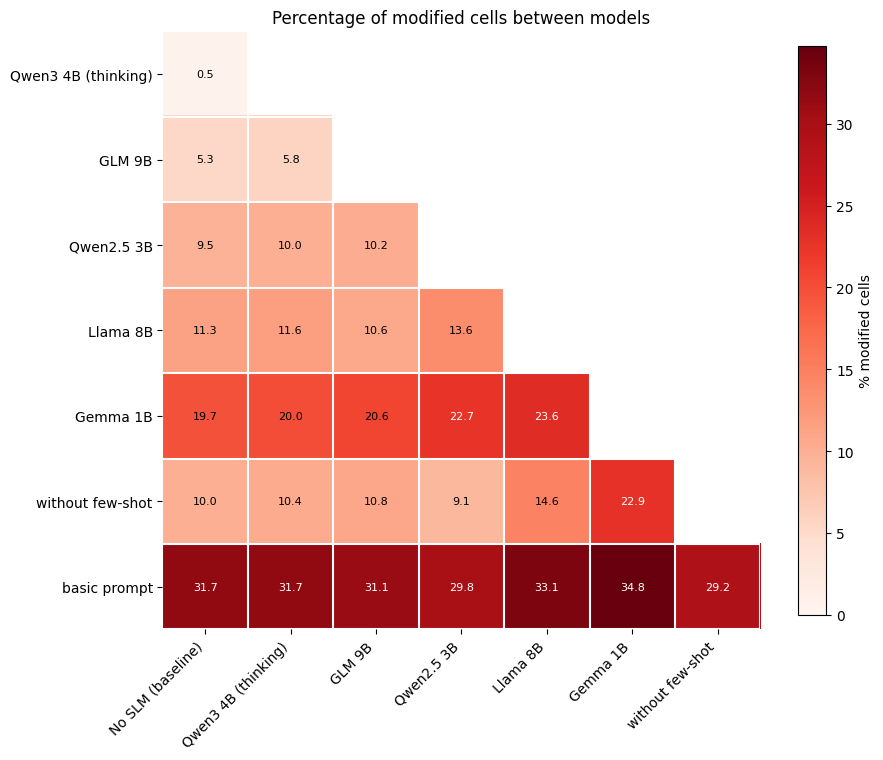

In [6]:
import numpy as np
import matplotlib.pyplot as plt

models = [folder_nollm, folder_qwen3, folder_glm, folder_qwen2, folder_llama, folder_gemma, folder_no_few_shot, folder_basic]
display_names = {
    folder_nollm: "No SLM (baseline)",
    folder_qwen3: "Qwen3 4B (thinking)",
    folder_glm: "GLM 9B",
    folder_qwen2: "Qwen2.5 3B",
    folder_llama: "Llama 8B",
    folder_gemma: "Gemma 1B",
    folder_no_few_shot: "without few-shot",
    folder_basic: "basic prompt",
}
labels = [display_names[m] for m in models]
n = len(labels)

pct = pd.DataFrame(np.nan, index=labels, columns=labels)
for i in range(n):
    for j in range(i): 
        common, nonempty, counts, target_nonempty, target_counts, changes = diff_folders(models[i], models[j])
        pct.iloc[i, j] = 100 * (nonempty - counts["same"]) / nonempty if nonempty else 0.0

pct = pct.iloc[1:, :-1]
row_labels = list(pct.index)
col_labels = list(pct.columns)
n_rows, n_cols = pct.shape

data = np.ma.masked_invalid(pct.values)
vmax = np.nanmax(pct.values)

cmap = plt.get_cmap("Reds").copy()
cmap.set_bad("white")

fig, ax = plt.subplots(figsize=(0.9 * n_cols + 3, 0.9 * n_rows + 2))
im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vmax)

ax.set_xticks(range(n_cols)); ax.set_xticklabels(col_labels, rotation=45, ha="right")
ax.set_yticks(range(n_rows)); ax.set_yticklabels(row_labels)

for i in range(n_rows):
    for j in range(n_cols):
        v = pct.iloc[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:.1f}", ha="center", va="center",color="white" if v > 0.6 * vmax else "black", fontsize=8)

ax.set_xticks(np.arange(-.5, n_cols, 1), minor=True)
ax.set_yticks(np.arange(-.5, n_rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.5)
ax.tick_params(which="minor", length=0)
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title("Percentage of modified cells between models")
fig.colorbar(im, ax=ax, label="% modified cells", shrink=0.8)
plt.tight_layout()
plt.show()

In [7]:
import json
import time
import requests

GT_FILE = "Testing_data/cea_gt.csv"
CACHE_FILE = "../wikidata_cache.json"
API_URL = "https://www.wikidata.org/w/api.php"
USER_AGENT = "SemTabThesisBot/1.0 (https://github.com/LeiY769; contact: leiyang677@gmail.com)"

def get_labels(qids, language="en"):
    out = {}
    qids = [q for q in dict.fromkeys(qids) if q]
    for i in range(0, len(qids), 50):
        chunk = qids[i:i + 50]
        r = requests.get(API_URL, params={"action": "wbgetentities", "ids": "|".join(chunk), "props": "labels", "languages": f"{language}|en", "format": "json"}, headers={"User-Agent": USER_AGENT}, timeout=30)
        data = r.json() if r.status_code == 200 else None
        if not data or "error" in data:
            continue
        for qid, entity in data.get("entities", {}).items():
            labels = entity.get("labels", {})
            lab = labels.get(language) or labels.get("en")
            out[qid] = lab["value"] if lab else qid
        time.sleep(0.1)
    return out
def gold_labels(gt_file=GT_FILE, cache_file=CACHE_FILE, language="en"):
    gt = pd.read_csv(gt_file, names=["tab_id", "row_id", "col_id", "entity"], dtype=str, keep_default_na=False)
    gt["qid"] = gt["entity"].str.replace("http://www.wikidata.org/entity/", "", regex=False)
    labels = {}
    if os.path.exists(cache_file):
        with open(cache_file, encoding="utf-8") as f:
            labels = {q: v.get("label", "") for q, v in json.load(f).items()}
    missing = sorted({q for q in gt["qid"] if not labels.get(q)})
    if missing:
        print(f"Fetching {len(missing)} missing labels from Wikidata")
        labels.update(get_labels(missing, language))
    gold = {}
    for r in gt.itertuples():
        gold.setdefault(r.tab_id, []).append((int(r.row_id) - 1, int(r.col_id), labels.get(r.qid, "")))
    return gold
def compare_folder_to_gold(folder, gold):
    counts = {"same": 0, "case": 0, "real": 0}
    dist = {}
    diffs = []
    for tab_id in sorted(gold):
        path = os.path.join(folder, tab_id + ".csv")
        if not os.path.exists(path):
            continue
        df, _ = read_table(path)
        for row, col, label in gold[tab_id]:
            if not label or row >= len(df) or col >= df.shape[1]:
                continue
            value = str(df.iat[row, col])
            kind = classify_change(value, label)
            counts[kind] += 1
            d = levenshtein(norm_ws(value).casefold(), norm_ws(label).casefold())
            dist[(tab_id, row, col)] = d
            if kind == "real":
                diffs.append({"file": tab_id, "row": row, "col": col, "value": value, "label": label, "distance": d})
    return counts, dist, diffs
def report_vs_gold(folders, baseline_folder, sample=5):
    gold = gold_labels()
    _, base_dist, _ = compare_folder_to_gold(baseline_folder, gold)
    for folder in folders:
        counts, dist, diffs = compare_folder_to_gold(folder, gold)
        total = sum(counts.values())
        mean_d = sum(dist.values()) / len(dist) if dist else 0.0
        print(f"== {folder} ==")
        print(f"GT cells compared: {total}")
        print(f"Cell equals the Wikidata label: {counts['same']} ({100 * counts['same'] / total:.2f}%)  case/space-only diff: {counts['case']} ({100 * counts['case'] / total:.2f}%)")
        print(f"Cell differs from the label: {counts['real']} ({100 * counts['real'] / total:.2f}%)")
        print(f"Mean Levenshtein distance to the label: {mean_d:.2f}")
        if folder != baseline_folder:
            improved = sum(1 for k, d in dist.items() if k in base_dist and d < base_dist[k])
            worsened = sum(1 for k, d in dist.items() if k in base_dist and d > base_dist[k])
            print(f"vs {baseline_folder}: closer to label: {improved}, further from label: {worsened}")
            moved_away = sorted((r for r in diffs if r["distance"] > base_dist.get((r["file"], r["row"], r["col"]), r["distance"])), key=lambda r: -r["distance"])
            for r in moved_away[:sample]:
                print(f"  worsened: {r['file']} ({r['row']},{r['col']}): '{r['value']}' vs label '{r['label']}'")
        print()

report_vs_gold([folder_nollm, folder_basic, folder_no_few_shot, folder_gemma,folder_glm, folder_llama, folder_qwen2, folder_qwen3], folder_nollm)

Fetching 3601 missing labels from Wikidata
== Testing_data/Preprocessing/preprocessing_nollm ==
GT cells compared: 4247
Cell equals the Wikidata label: 3679 (86.63%)  case/space-only diff: 39 (0.92%)
Cell differs from the label: 529 (12.46%)
Mean Levenshtein distance to the label: 0.74

== Testing_data/Preprocessing/preprocessing_basic_prompt ==
GT cells compared: 4247
Cell equals the Wikidata label: 2045 (48.15%)  case/space-only diff: 425 (10.01%)
Cell differs from the label: 1777 (41.84%)
Mean Levenshtein distance to the label: 4.60
vs Testing_data/Preprocessing/preprocessing_nollm: closer to label: 79, further from label: 1508
  worsened: QN3CDMMP (0,0): 'Stall Krumbach 23; Krumbach 24 in Halsbach. (No spelling correction needed as there are no misspelled words.)' vs label 'Stall Krumbach 23; Krumbach 24 in Halsbach'
  worsened: UH3BGZJB (7,0): 'Cylindrical Pendant with Magical Writing (no spelling correction needed as it seems to be a title or name)' vs label 'Cylindrical Pendant 